In [1]:
# CELL 1 — Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from imblearn.over_sampling import SMOTE
import warnings, os, json, pickle
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

# Load all 10 CSV files
dataset_path = '/kaggle/input/datasets/bertvankeulen/cicids-2017/'
dfs = []
for f in sorted(os.listdir(dataset_path)):
    if f.endswith('.csv'):
        df_temp = pd.read_csv(
            os.path.join(dataset_path, f),
            encoding='utf-8', low_memory=False)
        df_temp.columns = df_temp.columns.str.strip()
        dfs.append(df_temp)
        print(f"✅ Loaded: {f} → {df_temp.shape[0]:,} rows")

df = pd.concat(dfs, ignore_index=True)
print(f"\n🎯 Full dataset: {df.shape}")

✅ Libraries loaded
✅ Loaded: friday.csv → 547,557 rows
✅ Loaded: friday_plus.csv → 547,557 rows
✅ Loaded: monday.csv → 371,621 rows
✅ Loaded: monday_plus.csv → 371,621 rows
✅ Loaded: thursday.csv → 362,075 rows
✅ Loaded: thursday_plus.csv → 362,075 rows
✅ Loaded: tuesday.csv → 322,078 rows
✅ Loaded: tuesday_plus.csv → 322,078 rows
✅ Loaded: wednesday.csv → 496,640 rows
✅ Loaded: wednesday_plus.csv → 496,640 rows

🎯 Full dataset: (4199942, 105)


In [2]:
# CELL 2 — Clean data
print("BEFORE cleaning:")
print(f"  Shape          : {df.shape}")
print(f"  Null values    : {df.isnull().sum().sum():,}")
print(f"  Duplicate rows : {df.duplicated().sum():,}")

# Step 1 — Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 2 — Drop rows with any null values
df.dropna(inplace=True)

# Step 3 — Drop duplicate rows
df.drop_duplicates(inplace=True)

# Step 4 — Reset index
df.reset_index(drop=True, inplace=True)

print("\nAFTER cleaning:")
print(f"  Shape          : {df.shape}")
print(f"  Null values    : {df.isnull().sum().sum():,}")
print(f"  Duplicate rows : {df.duplicated().sum():,}")
print(f"\n✅ Data cleaned successfully!")

BEFORE cleaning:
  Shape          : (4199942, 105)
  Null values    : 33,599,536
  Duplicate rows : 6,331

AFTER cleaning:
  Shape          : (2096807, 105)
  Null values    : 0
  Duplicate rows : 0

✅ Data cleaned successfully!


In [3]:
# CELL 3 — Encode labels
label_col = 'Label'

# Show original class distribution
print("CLASS DISTRIBUTION AFTER CLEANING:")
print("=" * 55)
counts = df[label_col].value_counts()
for cls, cnt in counts.items():
    pct = cnt / len(df) * 100
    print(f"  {cls:45s}: {cnt:>8,} ({pct:.2f}%)")

# Encode string labels to numbers
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df[label_col])

print(f"\n✅ Labels encoded:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} → {cls}")

CLASS DISTRIBUTION AFTER CLEANING:
  BENIGN                                       : 1,582,538 (75.47%)
  Portscan                                     :  159,066 (7.59%)
  DoS Hulk                                     :  158,468 (7.56%)
  DDoS                                         :   95,144 (4.54%)
  Infiltration - Portscan                      :   68,626 (3.27%)
  DoS GoldenEye                                :    7,567 (0.36%)
  Botnet - Attempted                           :    4,067 (0.19%)
  FTP-Patator                                  :    3,972 (0.19%)
  DoS Slowloris                                :    3,859 (0.18%)
  DoS Slowhttptest - Attempted                 :    3,368 (0.16%)
  SSH-Patator                                  :    2,961 (0.14%)
  DoS Slowloris - Attempted                    :    1,847 (0.09%)
  DoS Slowhttptest                             :    1,740 (0.08%)
  Web Attack - Brute Force - Attempted         :    1,292 (0.06%)
  Botnet                               

In [4]:
# CELL 4 — Split features and labels
# Drop non-numeric and label columns
drop_cols = [label_col, 'Label_encoded']
X = df.drop(columns=drop_cols)
y = df['Label_encoded']

# Keep only numeric columns
X = X.select_dtypes(include=np.number)

print(f"Features shape : {X.shape}")
print(f"Labels shape   : {y.shape}")
print(f"Unique classes : {y.nunique()}")
print(f"\nClass mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} → {cls}")

Features shape : (2096807, 102)
Labels shape   : (2096807,)
Unique classes : 27

Class mapping:
   0 → BENIGN
   1 → Botnet
   2 → Botnet - Attempted
   3 → DDoS
   4 → DoS GoldenEye
   5 → DoS GoldenEye - Attempted
   6 → DoS Hulk
   7 → DoS Hulk - Attempted
   8 → DoS Slowhttptest
   9 → DoS Slowhttptest - Attempted
  10 → DoS Slowloris
  11 → DoS Slowloris - Attempted
  12 → FTP-Patator
  13 → FTP-Patator - Attempted
  14 → Heartbleed
  15 → Infiltration
  16 → Infiltration - Attempted
  17 → Infiltration - Portscan
  18 → Portscan
  19 → SSH-Patator
  20 → SSH-Patator - Attempted
  21 → Web Attack - Brute Force
  22 → Web Attack - Brute Force - Attempted
  23 → Web Attack - SQL Injection
  24 → Web Attack - SQL Injection - Attempted
  25 → Web Attack - XSS
  26 → Web Attack - XSS - Attempted


Selecting top 20 features using Extra Trees...
(Using 200K sample for speed)

✅ Top 20 features selected:
   1. Local_1                                  importance: 0.1379
   2. Local_13                                 importance: 0.1336
   3. Local                                    importance: 0.0508
   4. Src IP dec                               importance: 0.0441
   5. Local_9                                  importance: 0.0326
   6. Bwd Packet Length Std                    importance: 0.0293
   7. FWD Init Win Bytes                       importance: 0.0276
   8. Protocol                                 importance: 0.0273
   9. Subflow Bwd Bytes                        importance: 0.0268
  10. Bwd Segment Size Avg                     importance: 0.0268
  11. Bwd Packet Length Mean                   importance: 0.0251
  12. Packet Length Mean                       importance: 0.0240
  13. Local_14                                 importance: 0.0231
  14. Bwd Packet Length Max         

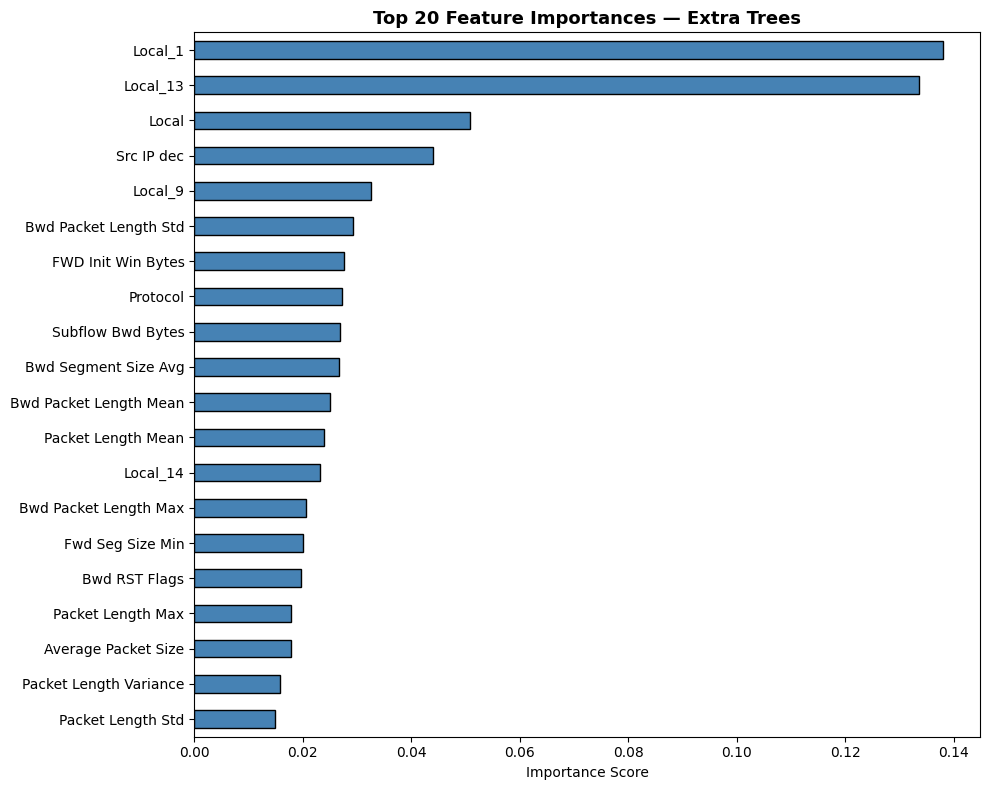

✅ Feature importance plot saved!


In [5]:
# CELL 5 — Feature selection using Extra Trees
# Use a sample for speed (Extra Trees on 4M rows is slow)
print("Selecting top 20 features using Extra Trees...")
print("(Using 200K sample for speed)")

# Sample for feature selection only
sample_idx = np.random.choice(len(X), 200000, replace=False)
X_sample = X.iloc[sample_idx]
y_sample = y.iloc[sample_idx]

# Train Extra Trees
etc = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
etc.fit(X_sample, y_sample)

# Get top 20 features
importances = pd.Series(
    etc.feature_importances_,
    index=X.columns
)
top_20_features = importances.nlargest(20).index.tolist()

print(f"\n✅ Top 20 features selected:")
for i, feat in enumerate(top_20_features):
    print(f"  {i+1:2d}. {feat:40s} "
          f"importance: {importances[feat]:.4f}")

# Plot feature importances
plt.figure(figsize=(10, 8))
importances[top_20_features].sort_values()\
    .plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances — Extra Trees',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance plot saved!")

In [6]:
# CELL 6 — Filter top 20 + train test split
X_selected = X[top_20_features]

print(f"Dataset after feature selection: {X_selected.shape}")

# Train test split — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")
print(f"\nClass distribution in train:")
train_counts = pd.Series(y_train).value_counts()
for cls_id, cnt in train_counts.items():
    print(f"  {le.classes_[cls_id]:40s}: {cnt:,}")

Dataset after feature selection: (2096807, 20)

Train set : (1677445, 20)
Test set  : (419362, 20)

Class distribution in train:
  BENIGN                                  : 1,266,030
  Portscan                                : 127,253
  DoS Hulk                                : 126,774
  DDoS                                    : 76,115
  Infiltration - Portscan                 : 54,901
  DoS GoldenEye                           : 6,053
  Botnet - Attempted                      : 3,253
  FTP-Patator                             : 3,178
  DoS Slowloris                           : 3,087
  DoS Slowhttptest - Attempted            : 2,694
  SSH-Patator                             : 2,369
  DoS Slowloris - Attempted               : 1,478
  DoS Slowhttptest                        : 1,392
  Web Attack - Brute Force - Attempted    : 1,034
  Botnet                                  : 589
  Web Attack - XSS - Attempted            : 524
  DoS Hulk - Attempted                    : 465
  DoS GoldenEye -

In [7]:
# CELL 7 — MinMax normalisation
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ MinMax normalisation applied")
print(f"  Min value in train: {X_train_scaled.min():.4f}")
print(f"  Max value in train: {X_train_scaled.max():.4f}")
print(f"  Train shape: {X_train_scaled.shape}")
print(f"  Test shape : {X_test_scaled.shape}")

✅ MinMax normalisation applied
  Min value in train: 0.0000
  Max value in train: 1.0000
  Train shape: (1677445, 20)
  Test shape : (419362, 20)


In [11]:
# CELL 8 — SAFEST VERSION — handles tiny classes
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import numpy as np

print("Applying SMOTE safely...")

# Check class counts
class_counts = Counter(y_train)
print("\nClass counts before SMOTE:")
for cls_id, cnt in sorted(class_counts.items(),
                           key=lambda x: -x[1]):
    print(f"  {le.classes_[cls_id]:40s}: {cnt:,}")

# Remove classes with less than 3 samples
# (SMOTE cannot handle them with k_neighbors=2)
min_samples = 3
valid_classes = [cls for cls, cnt
                 in class_counts.items()
                 if cnt >= min_samples]
invalid_classes = [cls for cls, cnt
                   in class_counts.items()
                   if cnt < min_samples]

if invalid_classes:
    print(f"\n⚠️  Removing {len(invalid_classes)} classes")
    print(f"    with less than {min_samples} samples:")
    for cls in invalid_classes:
        print(f"    - {le.classes_[cls]} ({class_counts[cls]} samples)")

# Filter to valid classes only
mask = np.isin(y_train, valid_classes)
X_train_valid = X_train_scaled[mask]
y_train_valid = y_train.values[mask]

print(f"\nSamples after filtering: {len(X_train_valid):,}")
print(f"Classes remaining      : {len(valid_classes)}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_bal, y_train_bal = smote.fit_resample(
    X_train_valid, y_train_valid)

print(f"\nAFTER SMOTE:")
after = pd.Series(y_train_bal).value_counts()
for cls_id, cnt in after.items():
    print(f"  {le.classes_[cls_id]:40s}: {cnt:,}")

print(f"\n✅ SMOTE complete!")
print(f"  Before : {X_train_scaled.shape[0]:,} samples")
print(f"  After  : {X_train_bal.shape[0]:,} samples")


Applying SMOTE safely...

Class counts before SMOTE:
  BENIGN                                  : 1,266,030
  Portscan                                : 127,253
  DoS Hulk                                : 126,774
  DDoS                                    : 76,115
  Infiltration - Portscan                 : 54,901
  DoS GoldenEye                           : 6,053
  Botnet - Attempted                      : 3,253
  FTP-Patator                             : 3,178
  DoS Slowloris                           : 3,087
  DoS Slowhttptest - Attempted            : 2,694
  SSH-Patator                             : 2,369
  DoS Slowloris - Attempted               : 1,478
  DoS Slowhttptest                        : 1,392
  Web Attack - Brute Force - Attempted    : 1,034
  Botnet                                  : 589
  Web Attack - XSS - Attempted            : 524
  DoS Hulk - Attempted                    : 465
  DoS GoldenEye - Attempted               : 64
  Web Attack - Brute Force                : 58

In [13]:
# CELL 9 — Save all processed data
import pickle, os, json

save_path = '/kaggle/working/'
os.makedirs(save_path, exist_ok=True)

print("Saving files... please wait...")

# Save numpy arrays
print("Saving X_train.npy ...")
np.save(f'{save_path}X_train.npy', X_train_bal)

print("Saving X_test.npy ...")
np.save(f'{save_path}X_test.npy',  X_test_scaled)

print("Saving y_train.npy ...")
np.save(f'{save_path}y_train.npy', y_train_bal)

print("Saving y_test.npy ...")
np.save(f'{save_path}y_test.npy',  y_test.values)

# Save scaler and encoders
with open(f'{save_path}scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(f'{save_path}label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open(f'{save_path}top_features.pkl', 'wb') as f:
    pickle.dump(top_20_features, f)

# Save summary
summary = {
    'X_train_shape'   : list(X_train_bal.shape),
    'X_test_shape'    : list(X_test_scaled.shape),
    'n_classes'       : int(len(le.classes_)),
    'class_names'     : le.classes_.tolist(),
    'top_20_features' : top_20_features,
    'train_samples'   : int(X_train_bal.shape[0]),
    'test_samples'    : int(X_test_scaled.shape[0])
}
with open(f'{save_path}preprocessing_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Confirm all saved
print("\n✅ ALL FILES SAVED:")
print("=" * 40)
for fname in sorted(os.listdir(save_path)):
    size = os.path.getsize(
           f'{save_path}{fname}') // 1024 // 1024
    print(f"  └── {fname:<35s} {size:>5} MB")

print(f"\n🎉 DAY 2 PREPROCESSING COMPLETE!")
print(f"   Train : {X_train_bal.shape[0]:,} samples")
print(f"   Test  : {X_test_scaled.shape[0]:,} samples")
print(f"   Features : {X_train_bal.shape[1]}")
print(f"   Classes  : {len(le.classes_)}")
print(f"\n✅ Ready for Day 3 — ML Baseline Models!")


Saving files... please wait...
Saving X_train.npy ...
Saving X_test.npy ...
Saving y_train.npy ...
Saving y_test.npy ...

✅ ALL FILES SAVED:
  └── .virtual_documents                      0 MB
  └── X_test.npy                             63 MB
  └── X_train.npy                          5215 MB
  └── feature_importance.png                  0 MB
  └── label_encoder.pkl                       0 MB
  └── preprocessing_summary.json              0 MB
  └── scaler.pkl                              0 MB
  └── top_features.pkl                        0 MB
  └── y_test.npy                              3 MB
  └── y_train.npy                           260 MB

🎉 DAY 2 PREPROCESSING COMPLETE!
   Train : 34,182,810 samples
   Test  : 419,362 samples
   Features : 20
   Classes  : 27

✅ Ready for Day 3 — ML Baseline Models!
